In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## **Importing Dependencies**
---

In [24]:
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
from visual_utils_pipeline_universal import plot_all_distributions

## **Fetching Datasets**
---

In [25]:
"""
1. The "SQL Power" Move (Filtering)
The beauty of using sqlite3 is that you don't have to load the entire dataset 
if you only want a specific part.
For example, if you wanted to look only at houses in a specific neighborhood or those 
built after the year 2000, you could do it directly in the query.
conn = sqlite3.connect('house_prices.db')

# Only pull houses with a Garage and more than 2 bathrooms
query = """
# SELECT * FROM train_records 
# WHERE GarageCars > 0 AND FullBath >= 2
"""
df_filtered = pd.read_sql(query, conn)
conn.close()
"""

# Connect to the database file you created with db_setup.py
conn = sqlite3.connect('house_prices.db')

# Pull the entire training table into a DataFrame
df_train = pd.read_sql("SELECT * FROM train_records", conn)

# Pull the test table
df_test = pd.read_sql("SELECT * FROM test_records", conn)

# Always close the connection when you're done loading
conn.close()

# Check the results
print(f"Dataset loaded! Train shape: {df_train.shape}")
print(df_train.info())
df_train.head()

Dataset loaded! Train shape: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000


## **Exploratory Data Analysis (EDA)**
---

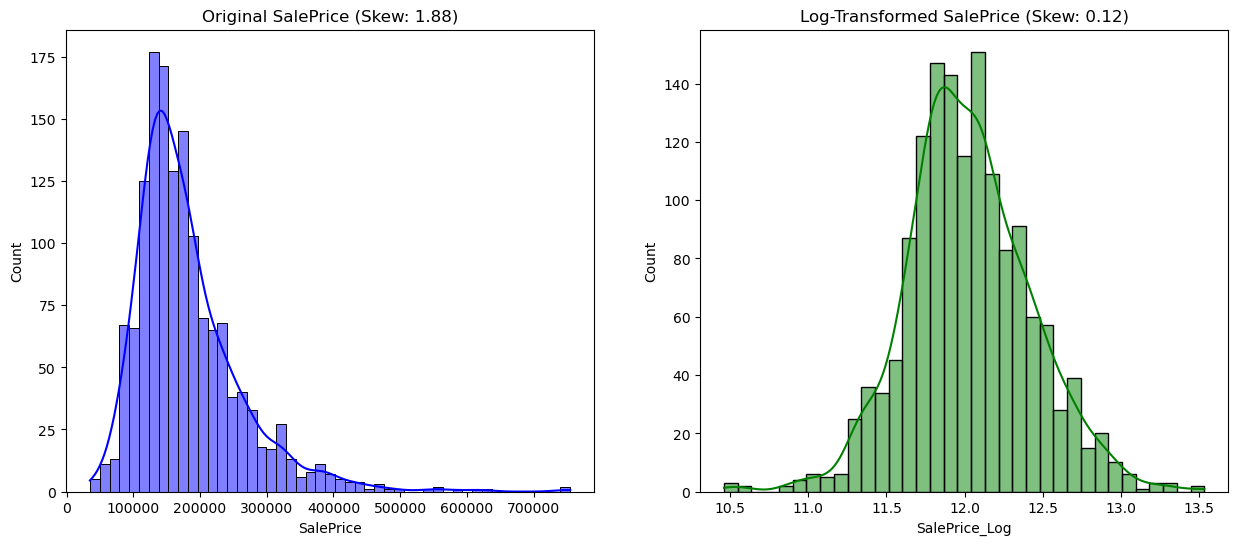

In [26]:
# Apply the log transformation to the target variable
df_train['SalePrice_Log'] = np.log1p(df_train['SalePrice'])

# Visualize the 'Before' and 'After' side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original
sns.histplot(df_train['SalePrice'], kde=True, ax=ax1, color='blue')
ax1.set_title(f"Original SalePrice (Skew: {df_train['SalePrice'].skew():.2f})")

# Transformed
sns.histplot(df_train['SalePrice_Log'], kde=True, ax=ax2, color='green')
ax2.set_title(f"Log-Transformed SalePrice (Skew: {df_train['SalePrice_Log'].skew():.2f})")

plt.show()

---

## **Error Log: SQLite Type Inference Mismatch**

**Problem Description:**
When loading data from the `house_prices.db` (SQLite), Pandas failed to automatically detect the numerical data types for several columns (e.g., `Id`, `MSSubClass`, `LotFrontage`). As a result, these were imported as `object` types. The `plot_all_distributions` function then treated these as categorical data, attempting to plot individual bars for every unique number, resulting in unreadable "crowded" charts.

**Original Erroring Code:**
```python
# The visualization function sees 'objects' instead of 'ints'
from visual_utils_pipeline_universal import plot_all_distributions
plot_all_distributions(df_train.iloc[:, :10])
```

**Observed Behavior:**
Numerical columns like `Id` appeared as a dense "wall" of blue bars on the x-axis because the visualizer was performing a frequency count (Categorical) rather than a binned histogram (Numerical).

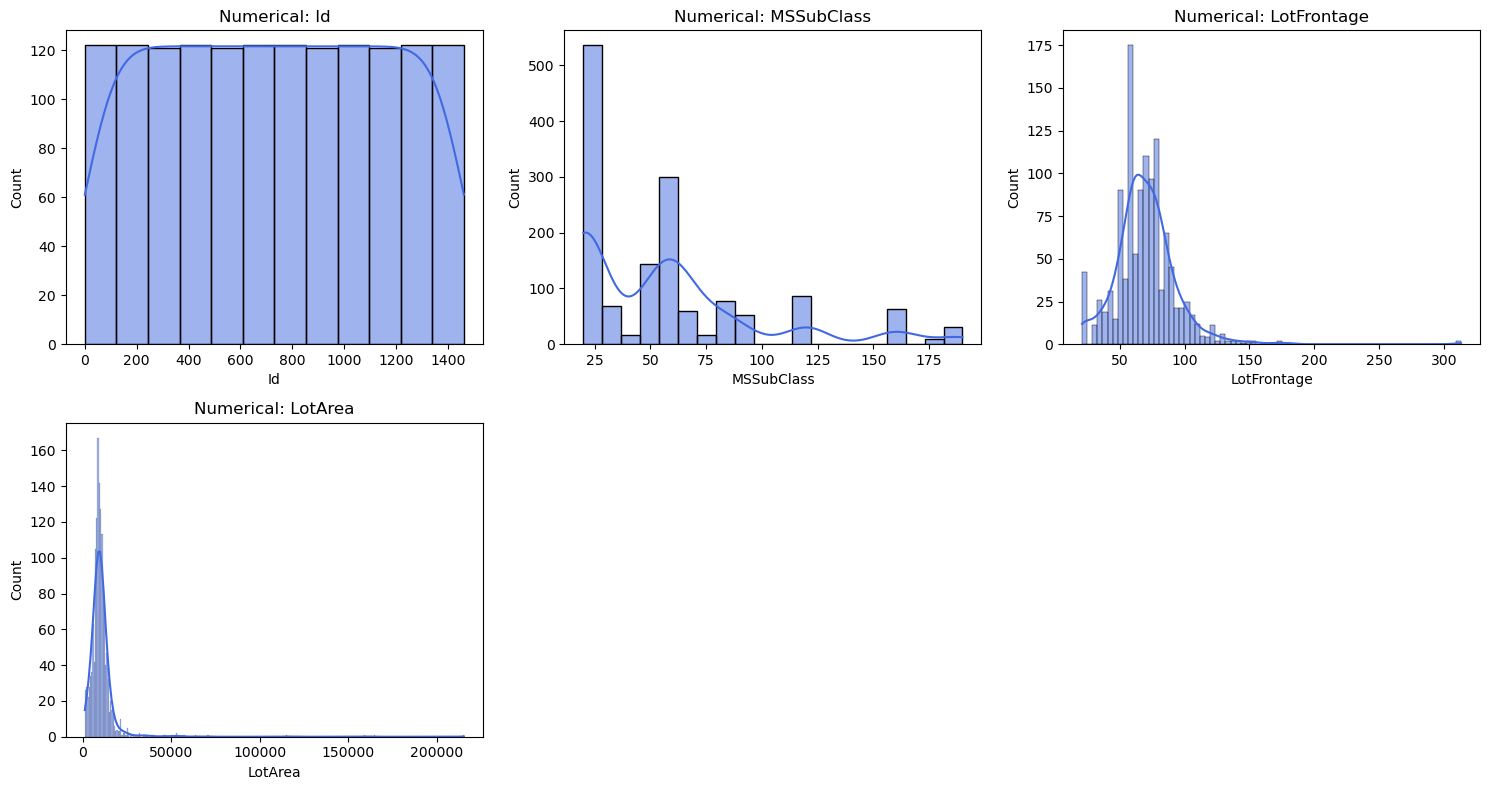

**Resolution:**
The data types must be explicitly "coerced" into numeric format after loading from SQLite. This allows Pandas to recognize integers and floats, which then triggers the correct histogram logic in the visualization module. We use errors='ignore' in the code. It is vital because if we tried to force a word like "Neighborhood" into a number, the code would crash—ignore keeps the actual text columns safe.

**Corrected Implementation:**

```python
# Force numeric conversion for all columns where possible
for col in df_train.columns:
    df_train[col] = pd.to_numeric(df_train[col], errors='ignore')

# Now the visualizer correctly generates histograms
plot_all_distributions(df_train.iloc[:, :10])
```

---

C:\Users\DANISH LAPTOP\AppData\Local\Temp\ipykernel_6172\2060302830.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_train[col] = pd.to_numeric(df_train[col], errors='ignore')


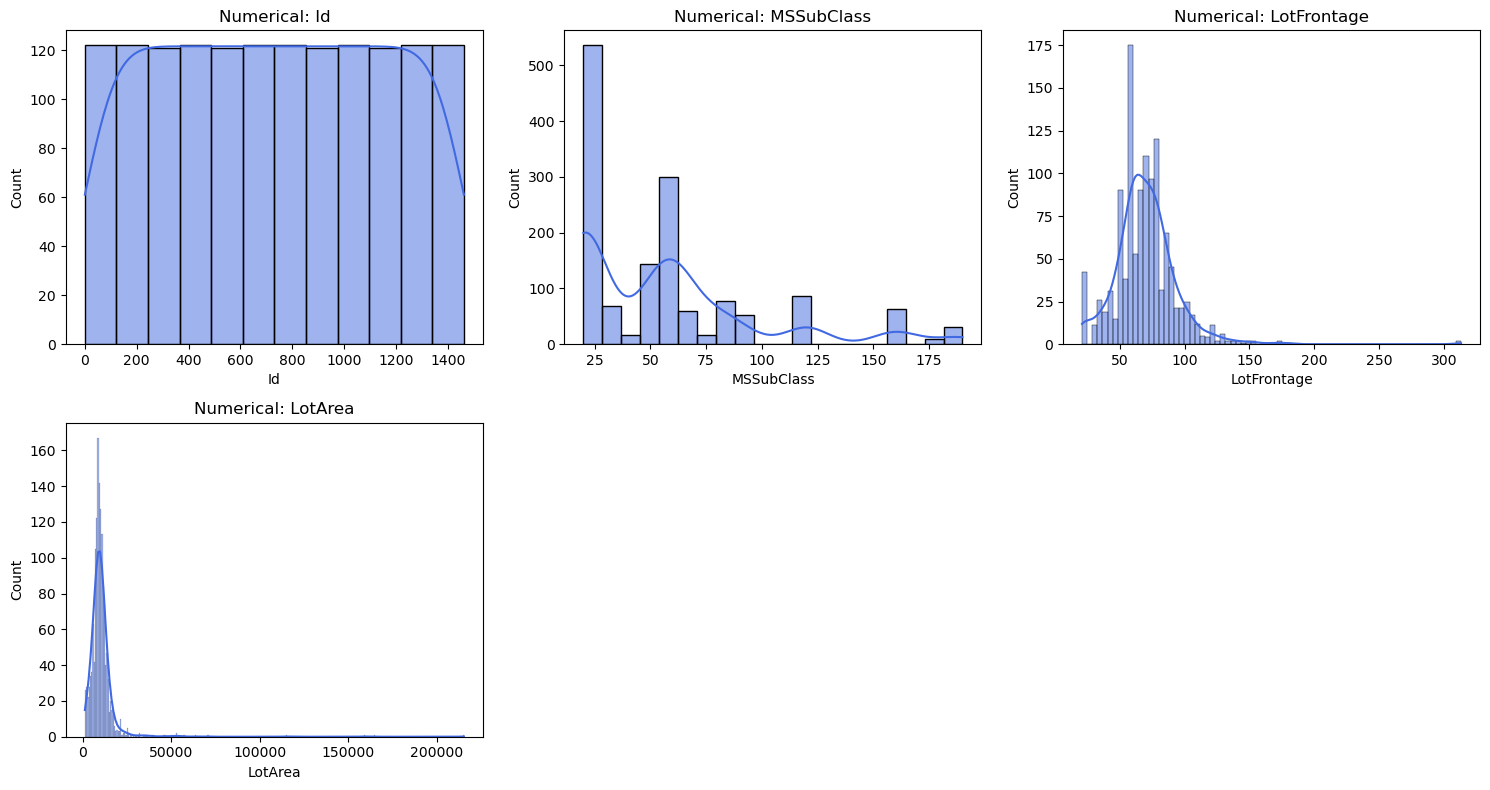

c:\Users\DANISH LAPTOP\Desktop\Machine Learning using VS Code, Git and GitHub\Machine-Learning-Projects\House-Price-Regression\visual_utils_pipeline_universal.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')  # Plot count plot for categorical data
c:\Users\DANISH LAPTOP\Desktop\Machine Learning using VS Code, Git and GitHub\Machine-Learning-Projects\House-Price-Regression\visual_utils_pipeline_universal.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')  # Plot count plot for categorical data
c:\Users\DANISH LAPTOP\Desktop\Machine Learning using VS Code, Git and GitHub\Machine-Learning-P

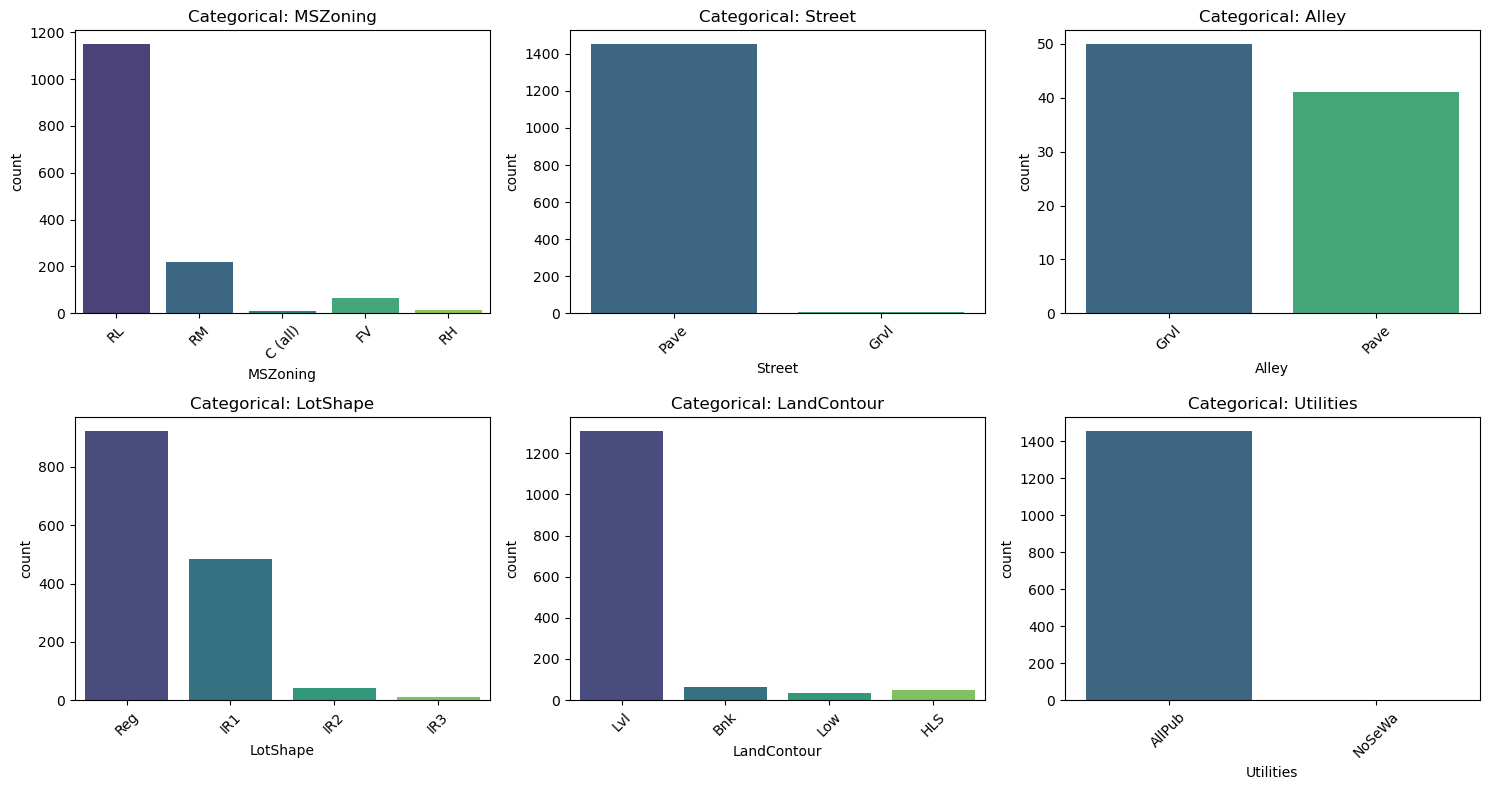

In [27]:
# Force numeric conversion for all columns where possible
for col in df_train.columns:
    df_train[col] = pd.to_numeric(df_train[col], errors='ignore')

# Now the visualizer correctly generates histograms
plot_all_distributions(df_train.iloc[:, :10])

In [28]:
X_train = df_train.drop(["SalePrice", "Id"], axis=1)
y_train = df_train["SalePrice"]
X_test = df_test.drop("Id", axis=1)

## **Preprocessing the Datasets**
---